# Orchestrating the text-to-query agent

With the tools and prompt created, we are finally ready to orchestrate the text-to-query agent.

In this course, we will use LangGraph for agent orchestration. With LangGraph, you can orchestrate LLM applications as graphs. Graphs in LangGraph have three main components, namely nodes, edges and state.

Nodes help you define the main logic of the graph, edges help define the flow of the graph, and the state is a shared data structure between all the nodes.

![](images/agent_orchestration.png)

**Run the two cells below to install the necessary libraries and enter your MongoDB connection string.**

In [15]:
!pip install -q langchain-openai==0.3.28 langgraph==0.6.3 pymongo==4.13.2 langchain-mongodb==0.6.2 pydantic==2.11.9


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [16]:
import os
from pymongo import MongoClient

MONGODB_URI = os.environ["MONGODB_URI"]
mongodb_client = MongoClient(MONGODB_URI)

**Run the hidden cell below to re-define the MongoDB database toolkit and prompt, and bind them in a chain with the LLM.**

In [17]:
from langchain_mongodb.agent_toolkit.database import MongoDBDatabase
from langchain_mongodb.agent_toolkit.toolkit import MongoDBDatabaseToolkit
from langchain_mongodb.agent_toolkit import MONGODB_AGENT_SYSTEM_PROMPT
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

db = MongoDBDatabase.from_connection_string(connection_string=MONGODB_URI, database="sample_mflix")
toolkit = MongoDBDatabaseToolkit(db=db, llm=llm)
tools = toolkit.get_tools()
tool_map = {tool.name:tool for tool in tools}

# Create a templated prompt for the LLM
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", MONGODB_AGENT_SYSTEM_PROMPT),
        ("system", "Always wrap _id in quotes when generating queries. Do not re-run tools unless absolutely necessary. If you are not able to get enough information using the tools, reply with I DON'T KNOW. You have access to the following tools: {tool_names}."),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

# Pre-fill top_k and tool_names in the prompt template
prompt = prompt.partial(top_k=5, tool_names=", ".join([tool.name for tool in tools]))

# Bind tools to the LLM
tool_augmented_llm = llm.bind_tools(tools)

# Chain the prompt and tool-augmented LLM
llm_with_tools = prompt | tool_augmented_llm

### Define graph state

First, let's define the state of our agent's graph.

To do this, we will use the `GraphState` class in LangGraph. In our case, the class will have only one attribute i.e. `messages` to track user and AI messages, but you can have additional attributes to track other information that you want the nodes in your graphs to share.

**Define the graph state using the `GraphState` class, with a single attribute called `messages`.**

In [18]:
from typing import Annotated
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict

class GraphState(TypedDict):
    messages: Annotated[list, add_messages]

Notice the type of the `messages` attribute: `Annotated[list, add_messages]`. This indicates that `messages` is a list and new messages are appended to it using the pre-built `add_messages` reducer function available in LangGraph.

Next, we will create the nodes of the graph, one of them being an agent node which uses a tool-augmented LLM to decide what actions to take.

However, we haven't yet given the LLM we initialized previously access the tools we created. We'd also want to give the LLM instructions on how to use these tools.

So let's do this before proceeding to create the nodes of the graph.

### Define graph nodes

Our text-to-query agent will have two nodes, an agent node, and a tool node.

Given a user query, it is first routed to the agent node which uses the tool-augmented LLM to decide the next action.

If the LLM decides to call a tool, the tool invocation payload is written to the graph's state. An example of what this looks like is as follows:
```
[{'name': 'mongodb_list_collections',
  'args': {},
  'id': 'call_qHNWqi22CP3Gqc8kdJbqv2Wy',
  'type': 'tool_call'}]
```
When the LLM decides that it has the final answer, it is also written to the graph state, and can be read from there to return to the user. We will see how later in the course.   


**Complete the code below to define the agent node that reads the `'messages'` attribute of the graph state, invokes the `llm_with_tools` with the messages, and appends the result to the `'messages'` attribute of the graph state.**

In [19]:
# Define the agent node
def agent_node(state):
    # Read "messages" from the graph state
    messages = state["messages"]
    # Invoke the tool-augmented LLM to determine next action
    result = llm_with_tools.invoke(messages)
    # Append the result to the graph state
    return {"messages": [result]}

**Complete the code below to define the tool node that reads the `.tool_calls` attribute of the most recent message in the graph state, extracts the name of the tool to execute (`"name"`), invokes it with the arguments (`"args"`) of the tool call, and appends the result to the `"messages"` attribute of the graph state.**

In [20]:
from langchain_core.messages import ToolMessage

# Define the tool node
def tool_node(state: GraphState):
    result = []
    # Read the tool invocation payload from the graph state
    tool_calls = state["messages"][-1].tool_calls
    for tool_call in tool_calls:
        # Extract the name of the tool to execute
        tool = tool_map[tool_call["name"]]
        # Invoke the tool with the arguments extracted from the payload
        observation = tool.invoke(tool_call["args"])
        # Create a ToolMessage to log the result of the tool execution
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    # Append the result to the graph state
    return {"messages": result}

If the LLM decides to call a tool, the control is passed to the tool node, which does the following:
* Reads the tool invocation payload from the graph state
* Executes the tool call with the arguments from the payload
* Writes the outcome from the tool call back to the graph state

In LangChain, there are  different types of `Messages` to distinguish between user, AI, tool messages etc. The `ToolMessage` object is specifically used to pass the result of tool execution back to a model.

### Build the graph

Now, let's connect the nodes and edges to build the graph for our text-to-query agent.

**Initialize the graph using the `StateGraph` class in LangGraph, with the graph state (`GraphState`) we defined previously.**

In [21]:
from langgraph.graph import StateGraph

# Initialize the graph with graph state
graph = StateGraph(GraphState)

In our text-to-query agent, we have fixed edges from the `START` node to `agent`, and from `tools` to `agent`. Then, we have conditional edges from `agent`to `tools` and `END`.

We will add fixed edges using the `.add_edge()` method in LangGraph. This method takes the source and target nodes, identified by their node IDs, as inputs.

For conditional edges, we will use the `.add_conditional_edges()` method with the pre-built `tools_condition` function in LangGraph that allows you to define the conditional routing logic.

**Add the nodes and edges (both fixed and conditional) to the graph.**

In [22]:
from langgraph.graph import START, END
from langgraph.prebuilt import tools_condition

# Add a node called "agent" that calls the agent_node() function 
graph.add_node("agent", agent_node)
# Add a node called "tools" that calls the tool_node() function 
graph.add_node("tools", tool_node)
# Add a fixed edge from the START node to the "agent" node 
graph.add_edge(START, "agent")
# Add a fixed edge from the "tools" node to the "agent" node
graph.add_edge("tools", "agent")
# Add conditional edges from the "agent" node to the "tools" and "END" nodes 
graph.add_conditional_edges(
    "agent",
    tools_condition,
    {"tools": "tools", END: END},
)

Finally, let's compile the graph using the `.compile()` method in LangGraph.

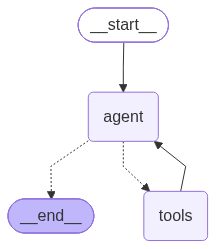

In [23]:
# Compile and visualize the graph
app = graph.compile()
app

### Test the agent

Finally, let's test out the agent with some sample queries.

Let's write a helper function to print the agent outputs nicely. We will stream the outputs from the agent as they produced using the `.stream()` method in LangGraph, and we will use the `.pretty_print()` method which formats the messages to make them more readable.

In [24]:
def execute_graph(user_input: str) -> None:
    """
    Stream outputs from the graph

    Args:
        user_input (str): User query string
    """
    # Stream outputs from each step in the graph
    for step in app.stream(
        {"messages": [{"role": "user", "content": user_input}]},
        # Stream full value of the state after each step
        stream_mode="values",
    ):
        # Print the latest message from the step
        step["messages"][-1].pretty_print()

execute_graph("Give me the top 5 directors by IMDB rating, who have made at least 20 movies")

================================ Human Message =================================

Give me the top 5 directors by IMDB rating, who have made at least 20 movies
================================== Ai Message ==================================
Tool Calls:
  mongodb_list_collections (call_Xgw278DDd24hhRyNZCXzxAAQ)
 Call ID: call_Xgw278DDd24hhRyNZCXzxAAQ
  Args:
================================= Tool Message =================================

comments, embedded_movies, movies, sessions, theaters, users
================================== Ai Message ==================================
Tool Calls:
  mongodb_schema (call_3qlDiHkezzg7XKd6OCBZyKNX)
 Call ID: call_3qlDiHkezzg7XKd6OCBZyKNX
  Args:
    collection_names: movies
================================= Tool Message =================================

Database name: sample_mflix
Collection name: movies
Schema from a sample of documents from the collection:
_id: ObjectId
plot: String
genres: Array<String>
runtime: Number
cast: Array<String>
poste

Using the above test, we can clearly see the steps taken by our text-to-query agent to arrive at an answer, including what tools were called, the arguments of the tool calls etc.

Feel free to try out more complex queries to identify edge cases and discover where the agent might struggle and need refinement.